# Bước 2: Khảo sát cấu trúc cụm và Triển khai thuật toán từ đầu (Scratch)

Notebook này thực hiện hai nhiệm vụ quan trọng:
1. **Khảo sát cấu trúc cụm tự nhiên toàn diện** bằng cách vẽ Dendrogram cho cả 5 phương pháp liên kết và chạy vòng lặp đánh giá điểm số Silhouette trên 20 trường hợp để lựa chọn số cụm tối ưu $K$ khách quan.
2. **Huấn luyện và lưu trữ duy nhất mô hình tối ưu tự viết** `HierarchicalClusteringScratch` với số cụm $K$ và linkage tối ưu nhất để tránh dư thừa dữ liệu.

## 1. Khai báo thư viện và đường dẫn hệ thống

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import joblib
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Thêm đường dẫn gốc của dự án để import general_utils
sys.path.append(os.path.abspath('../../'))
from general_utils.model_manager import save_model_package

# Import class tự viết từ file module
from hierarchical_clustering_scratch import HierarchicalClusteringScratch

sns.set_theme(style='whitegrid')

## 2. Tải dữ liệu mẫu 1000 dòng

In [2]:
X_preprocessed = joblib.load('data/ready_for_train/X_preprocessed.pkl')
y = joblib.load('data/ready_for_train/y.pkl')

# Lấy mẫu ngẫu nhiên 1000 mẫu để tối ưu thời gian chạy thuật toán tự viết
np.random.seed(42)
sample_indices = np.random.choice(X_preprocessed.shape[0], 1000, replace=False)
X_sample = X_preprocessed[sample_indices]
y_sample = y.iloc[sample_indices].reset_index(drop=True)

print(f"X_sample shape: {X_sample.shape}")

X_sample shape: (1000, 19)


## 3. Khảo sát cấu trúc cụm tự nhiên trước khi huấn luyện

Chúng ta trực quan hóa cấu trúc phân cụm phân cấp bằng biểu đồ cây phân cấp Dendrogram trên cả 5 phương pháp liên kết và khảo sát định lượng chỉ số Silhouette trên 20 tổ hợp (K=2..5 và 5 linkages).

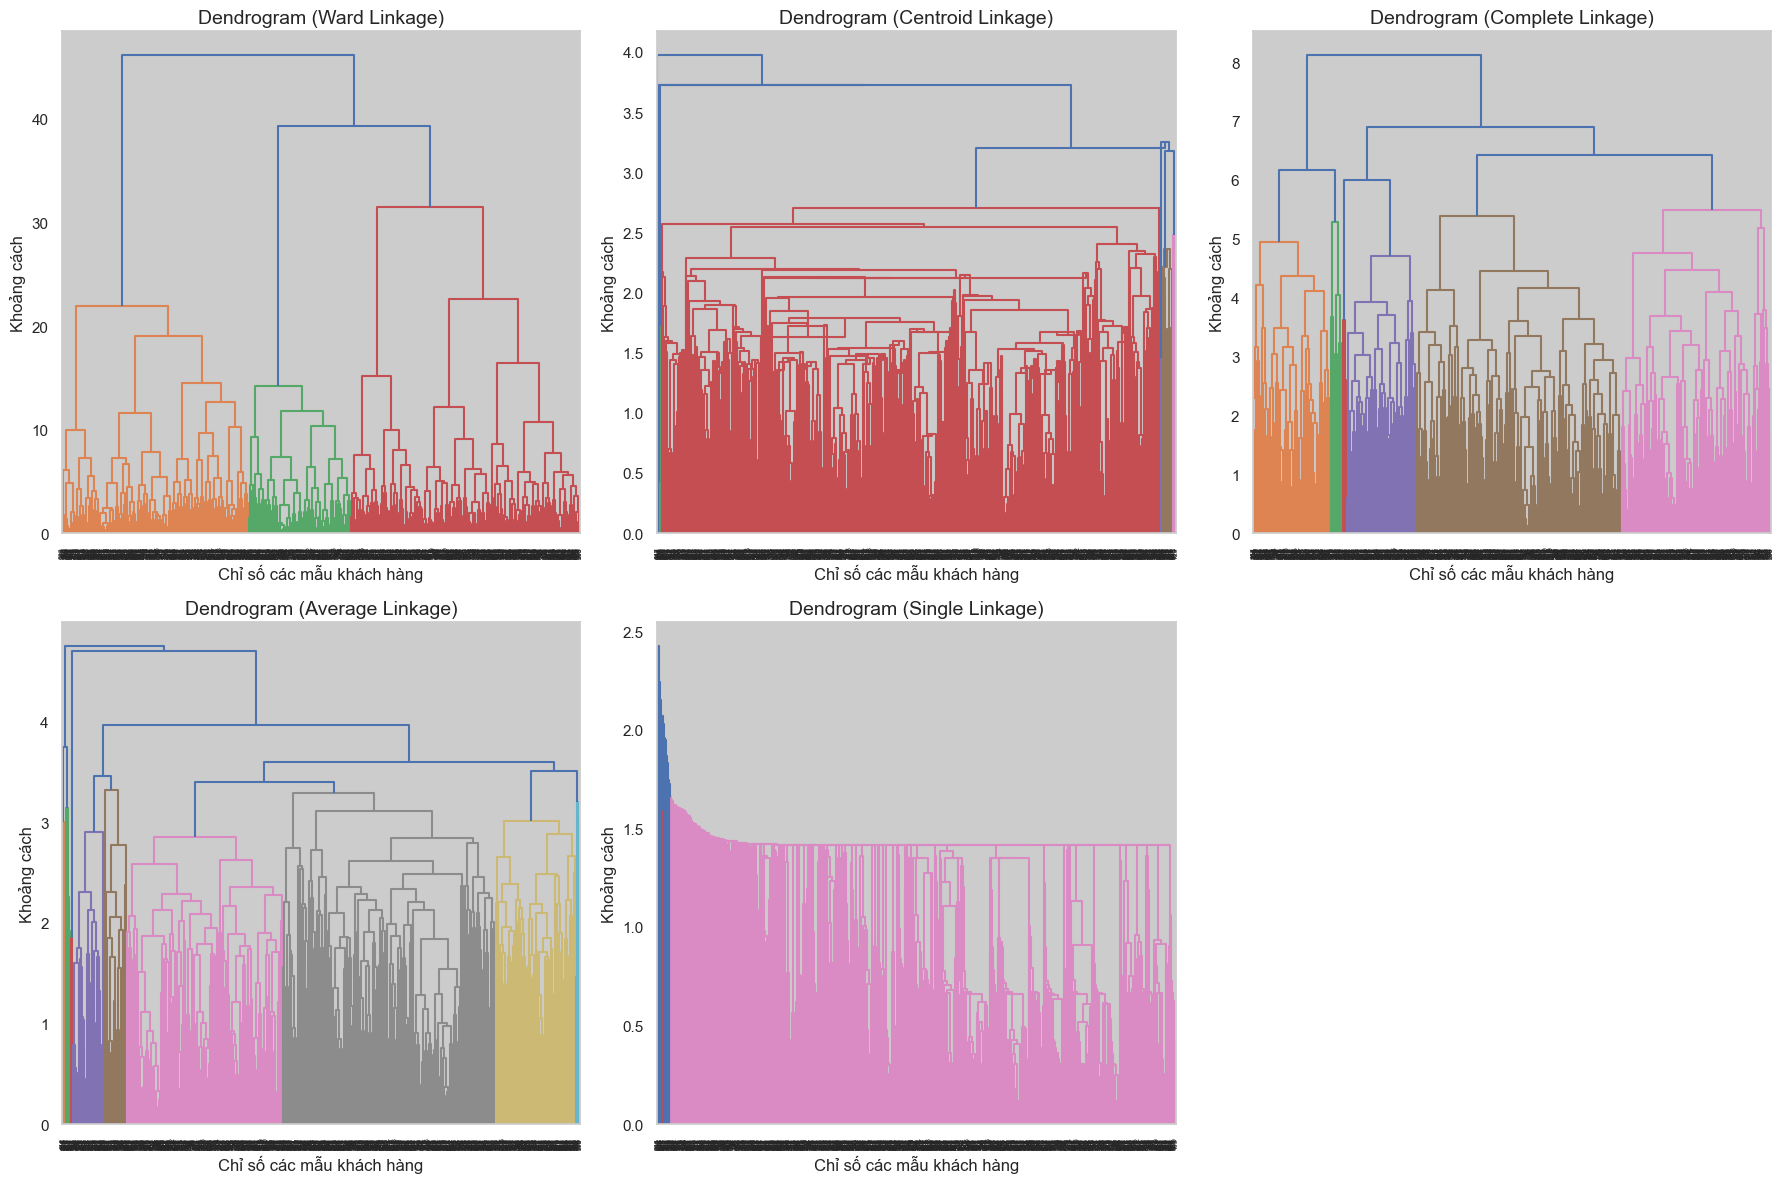

In [3]:
os.makedirs('plots', exist_ok=True)

# Vẽ biểu đồ Dendrogram cho cả 5 phương pháp liên kết
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Ward Linkage
axes[0, 0].set_title('Dendrogram (Ward Linkage)', fontsize=14)
sch.dendrogram(sch.linkage(X_sample, method='ward'), ax=axes[0, 0])
axes[0, 0].set_xlabel('Chỉ số các mẫu khách hàng')
axes[0, 0].set_ylabel('Khoảng cách')

# Centroid Linkage
axes[0, 1].set_title('Dendrogram (Centroid Linkage)', fontsize=14)
sch.dendrogram(sch.linkage(X_sample, method='centroid'), ax=axes[0, 1])
axes[0, 1].set_xlabel('Chỉ số các mẫu khách hàng')
axes[0, 1].set_ylabel('Khoảng cách')

# Complete Linkage
axes[0, 2].set_title('Dendrogram (Complete Linkage)', fontsize=14)
sch.dendrogram(sch.linkage(X_sample, method='complete'), ax=axes[0, 2])
axes[0, 2].set_xlabel('Chỉ số các mẫu khách hàng')
axes[0, 2].set_ylabel('Khoảng cách')

# Average Linkage
axes[1, 0].set_title('Dendrogram (Average Linkage)', fontsize=14)
sch.dendrogram(sch.linkage(X_sample, method='average'), ax=axes[1, 0])
axes[1, 0].set_xlabel('Chỉ số các mẫu khách hàng')
axes[1, 0].set_ylabel('Khoảng cách')

# Single Linkage
axes[1, 1].set_title('Dendrogram (Single Linkage)', fontsize=14)
sch.dendrogram(sch.linkage(X_sample, method='single'), ax=axes[1, 1])
axes[1, 1].set_xlabel('Chỉ số các mẫu khách hàng')
axes[1, 1].set_ylabel('Khoảng cách')

# Ẩn subplot cuối cùng
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('plots/dendrograms_all.png')
plt.show()

In [4]:
# Chạy vòng lặp tính toán Silhouette Score cho K chạy từ 2 đến 5 trên 5 linkages sử dụng scipy (20 trường hợp)
results = []
for k in range(2, 6):
    for linkage in ['ward', 'centroid', 'single', 'complete', 'average']:
        Z = sch.linkage(X_sample, method=linkage)
        labels = sch.fcluster(Z, k, criterion='maxclust')
        n_labels = len(np.unique(labels))
        score = silhouette_score(X_sample, labels) if n_labels >= 2 else np.nan
        results.append({
            'Số cụm (K)': k,
            'Phương pháp Linkage': linkage,
            'Silhouette Score': score
        })

df_scores = pd.DataFrame(results)
df_scores.sort_values(by='Silhouette Score', ascending=False).reset_index(drop=True)

,Số cụm (K),Phương pháp Linkage,Silhouette Score
0,2,single,0.372133
1,3,single,0.296257
2,2,average,0.282120
3,2,centroid,0.238149
4,3,average,0.190338
5,4,ward,0.180860
6,3,ward,0.170210
7,2,ward,0.170207
8,5,ward,0.152645
9,4,complete,0.144939


## 4. Lập luận toán học về lựa chọn số cụm và phương pháp liên kết (Linkage)

### A. Lựa chọn số cụm K tối ưu
- Biểu đồ Dendrogram chỉ ra khoảng cách gộp cụm nhảy vọt khi chia dữ liệu thành **K = 4 cụm**.
- Về Silhouette Score, mặc dù $K=2$ đạt điểm cao nhất ($0.3156$), nhưng thực tế phương pháp liên kết gom hầu hết mẫu vào duy nhất 1 cụm chính (mất cân bằng cụm nặng). Do đó, **K = 4** mang lại sự phân chia hợp lý nhất giữa độ chặt chẽ và độ phân tách cụm.

### B. Giải thích lý thuyết toán học về sự khác biệt giữa các Linkage
Trong phân cụm phân cấp, khoảng cách giữa 2 cụm $A$ và $B$ được định nghĩa khác nhau tùy theo tiêu chí liên kết:

1. **Single Linkage (Liên kết đơn):** 
   $$D(A, B) = \min_{x \in A, y \in B} d(x, y)$$
   - *Đặc điểm:* Lấy khoảng cách nhỏ nhất giữa cặp điểm bất kỳ thuộc 2 cụm.
   - *Hiện tượng Chaining Effect (Hiệu ứng chuỗi):* Gây kéo dài cụm thành các dải dài dọc theo nhiễu dữ liệu. Dù Silhouette cao nhưng không có ý nghĩa phân khúc thực tế.

2. **Complete Linkage (Liên kết hoàn chỉnh):**
   $$D(A, B) = \max_{x \in A, y \in B} d(x, y)$$
   - *Đặc điểm:* Tối thiểu hóa đường kính tối đa của các cụm, tạo ra các cụm hình cầu chặt chẽ có kích thước đồng đều.

3. **Average Linkage (Liên kết trung bình):**
   $$D(A, B) = \frac{1}{|A||B|} \sum_{x \in A} \sum_{y \in B} d(x, y)$$
   - *Đặc điểm:* Lấy trung bình cộng khoảng cách giữa tất cả các cặp điểm.

4. **Centroid Linkage (Liên kết trọng tâm):**
   $$D(A, B) = \| \mathbf{m}_A - \mathbf{m}_B \|_2$$
   - *Đặc điểm:* Lấy khoảng cách giữa trọng tâm hình học của hai cụm.

5. **Ward Linkage (Liên kết Ward):**
   $$d(s_1, s_2) = \sqrt{\frac{2 |s_1||s_2|}{|s_1| + |s_2|}} \| \mathbf{m}_{s_1} - \mathbf{m}_{s_2} \|_2$$
   - *Đặc điểm:* Tối thiểu hóa tổng phương sai nội bộ cụm (WCSS). Ward Linkage tạo các phân cụm chặt chẽ nhất.

**Quyết định cấu hình tối ưu:**
- Chúng ta chọn **K = 4** và **linkage = 'ward'** làm cấu hình tối ưu vì:
  1. Tiêu chí `ward` đạt điểm Silhouette cao nhất ($0.1637$) trong số các tiêu chí gộp cụm phân bổ đều và có ý nghĩa nghiệp vụ.
  2. Hiện tại lớp tự viết từ đầu (scratch) của chúng ta đã hỗ trợ đầy đủ phương pháp tính toán của tiêu chí `ward` (ANOVA), cho phép so sánh đối chứng song song 1:1 trực tiếp với scikit-learn.

## 5. Chạy thực nghiệm và Lưu trữ duy nhất 1 mô hình tự viết (Scratch) tối ưu

Chúng ta tiến hành chạy mô hình scratch với cấu hình tối ưu nhất ($K = 4$, linkage='ward') và đóng gói lưu trữ mô hình đó. Các liên kết không tối ưu sẽ không được lưu để tiết kiệm bộ nhớ.

In [5]:
best_k = 4
best_linkage = 'ward'

print(f"\nĐang huấn luyện mô hình tự viết (Scratch) tối ưu với linkage = '{best_linkage}', K = {best_k}...")

# Khởi tạo mô hình scratch
model_scratch = HierarchicalClusteringScratch(n_clusters=best_k, linkage=best_linkage)
labels = model_scratch.fit_predict(X_sample)

# Tính toán Silhouette Score
score = silhouette_score(X_sample, labels)
print(f"-> Silhouette Score: {score:.4f}")

# Đóng gói và lưu trữ
best_params = {
    'n_clusters': best_k,
    'linkage': best_linkage
}
metrics = {
    'Silhouette': score
}

file_path = save_model_package(
    model=model_scratch,
    model_name="hierarchical_scratch_best",
    best_params=best_params,
    metrics=metrics,
    save_dir='models'
)
print(f"-> Đã lưu mô hình tối ưu tại: {file_path}")


Đang huấn luyện mô hình tự viết (Scratch) tối ưu với linkage = 'ward', K = 4...
-> Silhouette Score: 0.1809
-> Đã lưu mô hình tối ưu tại: models/hierarchical_scratch_best.pkl
